<p style="font-size:24px;">Introduction</p>

<p style="font-size:16px;">
    This project focuses on analyzing retail e-commerce data to extract meaningful business insights. The dataset consists of multiple relational tables including customers, orders, products, payments, and reviews.

    The objective is to understand customer behavior, product performance, sales trends, and operational efficiency using data analytics techniques.
</p>

<p style="font-size:24px;">Section - 1</p>

<p style="font-size:16px;">Data Loading, Preprocessing and Understanding</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("Datasets/olist_customers_dataset.csv")
orders = pd.read_csv("Datasets/olist_orders_dataset.csv")
order_items = pd.read_csv("Datasets/olist_order_items_dataset.csv")
products = pd.read_csv("Datasets/olist_products_dataset.csv")
categories = pd.read_csv("Datasets/product_category_name_translation.csv")
payments = pd.read_csv("Datasets/olist_order_payments_dataset.csv")
reviews = pd.read_csv("Datasets/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("Datasets/olist_sellers_dataset.csv")
geolocations = pd.read_csv("Datasets/olist_geolocation_dataset.csv")

The dataset contains multiple tables:

    - Customers: Customer details and location
    - Orders: Order timestamps and status
    - Order Items: Product-level order details
    - Products: Product category information
    - Payments: Payment type and value
    - Reviews: Customer satisfaction scores

Basic Analysis 

In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [4]:
customers["customer_unique_id"].nunique()

96096

In [5]:
customers["customer_id"].nunique()

99441

In [6]:
customers.shape

(99441, 5)

In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [8]:
orders["order_id"].nunique()


99441

In [9]:
orders.shape

(99441, 8)

In [10]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [11]:
order_items["order_id"].nunique()

98666

In [12]:
order_items.shape

(112650, 7)

In [13]:
order_items["product_id"].nunique()

32951

In [14]:
products.info()
products

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [15]:
products["product_id"].nunique()


32951

In [16]:
products.shape

(32951, 9)

In [17]:
categories.info()
categories

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [18]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [19]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [20]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [21]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [22]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [23]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [24]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

The major missing values are present in the orders table and the products table, but when we look at the data, we can figure out that the missing data is just the delivery data maybe they are the data of orders that are not delivered till now and the others that are in progress or cancelled.

But when we look at the products table the data missing is the category of products. if we move forward with the same data there would be problem in analysis because category is the most important thing in the analysis.

In [25]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [26]:
product = products

<p style="font-size: 24px;">Section 2: <p>

<p style="font-size: 18px;">Top Product Categories By Revenue <p>

In [27]:
product = product.dropna(subset=["product_category_name"])

In [28]:
products = product

In [29]:
df = customers.merge(orders, on="customer_id", how="inner")

In [30]:
df = df.merge(order_items, on="order_id", how="inner")

In [31]:
df = df.merge(products, on="product_id", how="inner")

In [32]:

df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [33]:
df.shape

(111047, 26)

In [34]:
df["total_price"] = df["price"]+ df["freight_value"]

In [35]:
df["order_purchase_timestamp"]

0         2017-05-16 15:05:35
1         2018-01-12 20:48:24
2         2018-05-19 16:07:45
3         2018-03-13 16:06:38
4         2018-07-29 09:51:30
                 ...         
111042    2018-04-07 15:48:17
111043    2018-04-04 08:20:22
111044    2018-04-08 20:11:50
111045    2017-11-03 21:08:33
111046    2017-12-19 14:27:23
Name: order_purchase_timestamp, Length: 111047, dtype: str

In [36]:
df[["order_date", "order_time"]] = df["order_purchase_timestamp"].str.split(" ", expand=True)

In [37]:
df[["order_year", "order_month" , "order_day"]] = df["order_date"].str.split("-", expand=True)

In [38]:
df.drop(columns=["order_time", "order_date"], inplace = True)

In [39]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'total_price', 'order_year', 'order_month', 'order_day'],
      dtype='str')

In [40]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'total_price', 'order_year', 'order_month', 'order_day'],
      dtype='str')

In [41]:
df.drop(columns=["order_day"], inplace=True)

In [42]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'total_price', 'order_year', 'order_month'],
      dtype='str')

In [43]:
df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_price,order_year,order_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,146.87,2017,05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,335.48,2018,01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,157.73,2018,05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,173.30,2018,03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,252.25,2018,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111042,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,51.0,489.0,2.0,611.0,22.0,22.0,23.0,88.78,2018,04
111043,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0,129.06,2018,04
111044,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,60.0,575.0,1.0,870.0,25.0,20.0,18.0,56.04,2018,04
111045,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,59.0,452.0,1.0,710.0,19.0,13.0,14.0,711.07,2017,11


In [44]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [45]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [46]:
df["order_total"] = df.groupby("order_id")["total_price"].transform("sum")

In [47]:
df[["order_id", "total_price", "order_total"]].head()

,order_id,total_price,order_total
0,00e7ee1b050b8499577073aeb2a297a1,146.87,146.87
1,29150127e6685892b6eab3eec79f59c7,335.48,335.48
2,b2059ed67ce144a36e2aa97d2c9e9ad2,157.73,157.73
3,951670f92359f4fe4a63112aa7306eba,173.30,173.30
4,6b7d50bd145f6fc7f33cebabd7e49d0f,252.25,252.25


In [48]:
df[df["order_id"] == df["order_id"].value_counts().idxmax()][["order_id", "total_price", "order_total"]]

,order_id,total_price,order_total
52609,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52610,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52611,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52612,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52613,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52614,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52615,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52616,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52617,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17
52618,8272b63d03f5f79c56e9e4120aec44ef,9.09,196.17


In [49]:
df["product_category_name"].tolist()

['moveis_escritorio',
 'utilidades_domesticas',
 'moveis_escritorio',
 'moveis_escritorio',
 'casa_conforto',
 'esporte_lazer',
 'informatica_acessorios',
 'brinquedos',
 'moveis_decoracao',
 'automotivo',
 'informatica_acessorios',
 'climatizacao',
 'telefonia',
 'beleza_saude',
 'ferramentas_jardim',
 'automotivo',
 'pet_shop',
 'cama_mesa_banho',
 'telefonia',
 'informatica_acessorios',
 'ferramentas_jardim',
 'ferramentas_jardim',
 'ferramentas_jardim',
 'esporte_lazer',
 'bebes',
 'cama_mesa_banho',
 'relogios_presentes',
 'cama_mesa_banho',
 'moveis_cozinha_area_de_servico_jantar_e_jardim',
 'perfumaria',
 'cama_mesa_banho',
 'ferramentas_jardim',
 'ferramentas_jardim',
 'moveis_decoracao',
 'cama_mesa_banho',
 'cama_mesa_banho',
 'brinquedos',
 'esporte_lazer',
 'cama_mesa_banho',
 'artes',
 'moveis_escritorio',
 'informatica_acessorios',
 'relogios_presentes',
 'papelaria',
 'fashion_roupa_feminina',
 'esporte_lazer',
 'automotivo',
 'moveis_decoracao',
 'moveis_decoracao',
 'c

In [50]:
translation = {
    "beleza_saude": "beauty_health",
    "informatica_acessorios": "electronics_accessories",
    "automotivo": "automotive",
    "cama_mesa_banho": "bed_bath_table",
    "moveis_decoracao": "furniture_decor",
    "esporte_lazer": "sports_leisure",
    "perfumaria": "perfumery",
    "utilidades_domesticas": "home_utilities",
    "telefonia": "telephony",
    "relogios_presentes": "watches_gifts",
    "cool_stuff": "cool_stuff",
    "ferramentas_jardim": "garden_tools",
    "pet_shop": "pet_shop",
    "bebes": "baby",
    "papelaria": "stationery",
    "brinquedos": "toys",
    "eletronicos": "electronics",
    "fashion_bolsas_e_acessorios": "fashion_bags_accessories",
    "fashion_roupa_feminina": "women_fashion",
    "fashion_roupa_masculina": "men_fashion",
    "fashion_calcados": "footwear",
    "moveis_escritorio": "office_furniture",
    "moveis_sala": "living_room_furniture",
    "eletrodomesticos": "home_appliances",
    "eletrodomesticos_2": "home_appliances_2",
    "eletroportateis": "small_appliances",
    "climatizacao": "air_conditioning",
    "casa_construcao": "home_construction",
    "construcao_ferramentas_construcao": "construction_tools_construction",
    "construcao_ferramentas_ferramentas": "construction_tools_tools",
    "construcao_ferramentas_iluminacao": "construction_tools_lighting",
    "construcao_ferramentas_seguranca": "construction_tools_safety",
    "telefonia_fixa": "fixed_telephony",
    "alimentos_bebidas": "food_drinks",
    "alimentos": "food",
    "bebidas": "drinks",
    "market_place": "marketplace",
    "artes": "arts",
    "instrumentos_musicais": "musical_instruments",
    "livros_interesse_geral": "books_general",
    "dvds_blu_ray": "dvds_blu_ray",
    "cds_dvds_musicais": "cds_dvds_music",
    "malas_acessorios": "luggage_accessories",
    "casa_conforto": "home_comfort",
    "casa_conforto_2": "home_comfort",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "kitchen_dining_laundry_garden_furniture",
    "industria_comercio_e_negocios": "industry_business",
    "agro_industria_e_comercio": "agro_industry_commerce",
    "artigos_de_natal": "christmas_items",
    "fashion_underwear_e_moda_praia": "underwear_beachwear",
    "seguros_e_servicos": "insurance_services",
    "flores": "flowers"
}
df["product_category_name"] = df["product_category_name"].replace(translation)

In [51]:
top_5 = df.groupby("product_category_name")["total_price"].sum().sort_values(ascending=False)

The analysis shows that “Beleza Saúde” (Beauty & Health) is the highest revenue-generating category, followed closely by watches, home goods, and sports products. The relatively close revenue values among the top categories indicate a diversified sales distribution rather than dependence on a single category.

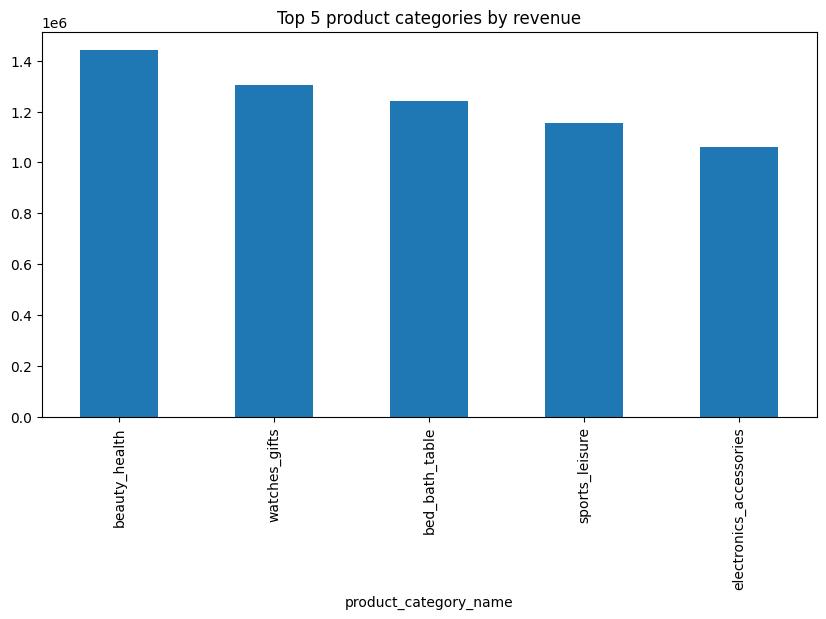

In [52]:
top_5.head().plot(kind="bar", title="Top 5 product categories by revenue", figsize=(10,5))
plt.show()

<p style="font-size: 18px;">Top Customer Analysis<p>

In [53]:
order_level = df.groupby("order_id").agg({
    "customer_id": "first",
    "order_total": "first"
})

In [54]:
top_customers = order_level.groupby("customer_id")["order_total"]\
    .sum()\
    .sort_values(ascending=False)\
    .head()

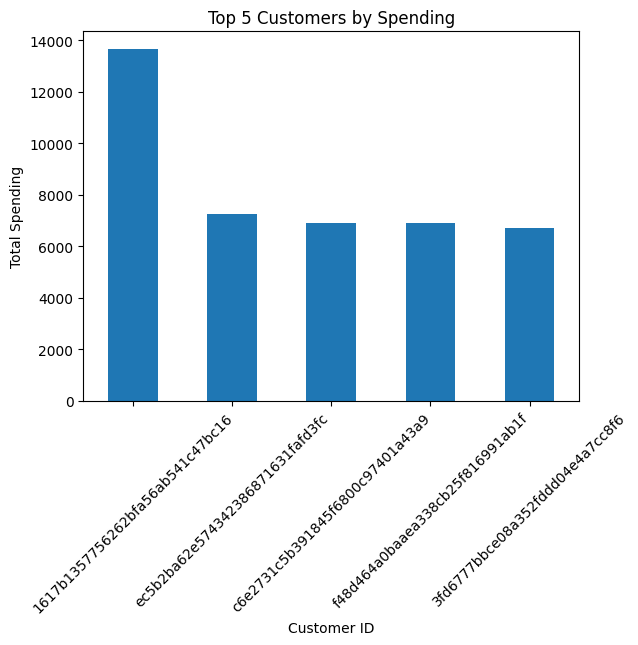

In [55]:
top_customers.plot(kind='bar')
plt.title("Top 5 Customers by Spending")
plt.ylabel("Total Spending")
plt.xlabel("Customer ID")
plt.xticks(rotation=45)
plt.show()

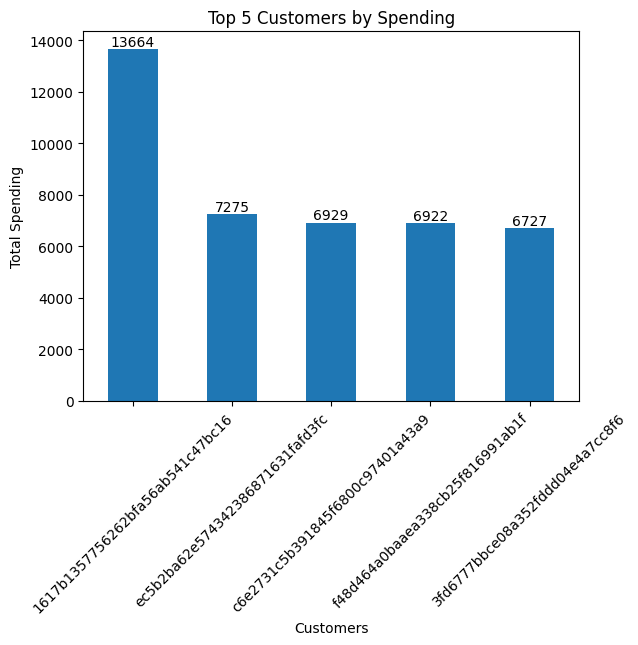

In [56]:
ax = top_customers.plot(kind='bar')

for i, v in enumerate(top_customers.values):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.title("Top 5 Customers by Spending")
plt.ylabel("Total Spending")
plt.xlabel("Customers")
plt.xticks(rotation=45)
plt.show()

In [57]:
top_customers_df = df.groupby("customer_id").agg({
    "order_total": "sum",
    "customer_city": "first"
}).sort_values(by="order_total", ascending=False).head()

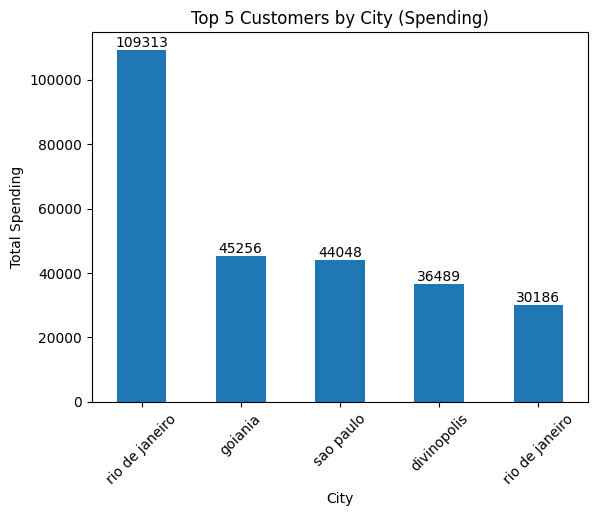

In [58]:
ax = top_customers_df.set_index("customer_city")["order_total"].plot(kind='bar')

for i, v in enumerate(top_customers_df["order_total"]):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.title("Top 5 Customers by City (Spending)")
plt.ylabel("Total Spending")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

The top customer contributes significantly higher revenue (~13.6k) compared to others (~6–7k), indicating a skewed spending distribution. This suggests a small group of high-value customers who can be targeted for retention strategies

This analysis identifies high-value customers contributing the most revenue.

In [59]:
df_cat = order_items.merge(products, on="product_id")

In [60]:
category_revenue = df_cat.groupby("product_category_name")["price"]\
    .sum()\
    .sort_values(ascending=False)\
    .head(10)

In [61]:
category_revenue = category_revenue.dropna()

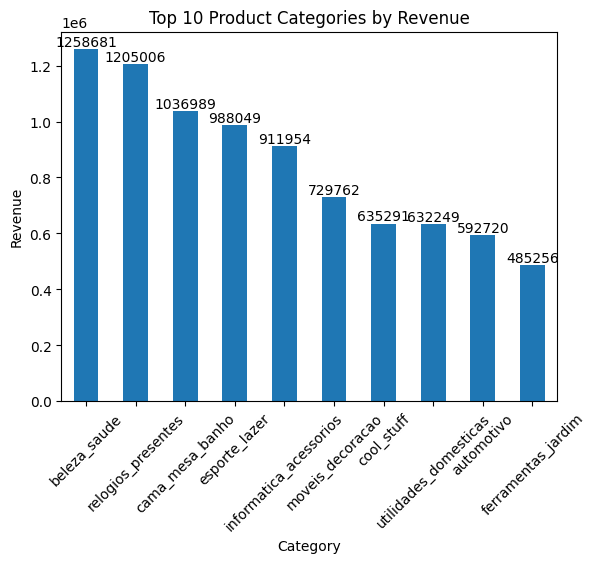

In [62]:
import matplotlib.pyplot as plt

ax = category_revenue.plot(kind='bar')

for i, v in enumerate(category_revenue.values):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom')

plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

In [63]:
category_revenue.index = category_revenue.index.str.replace("_", " ").str.title()

/var/folders/g1/bcp6xhrx4b920zt4dnsjykg00000gn/T/ipykernel_43141/2254628559.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(x/1000)}K' for x in ax.get_yticks()])


[Text(0, 0.0, '0K'),
 Text(0, 200000.0, '200K'),
 Text(0, 400000.0, '400K'),
 Text(0, 600000.0, '600K'),
 Text(0, 800000.0, '800K'),
 Text(0, 1000000.0, '1000K'),
 Text(0, 1200000.0, '1200K'),
 Text(0, 1400000.0, '1400K')]

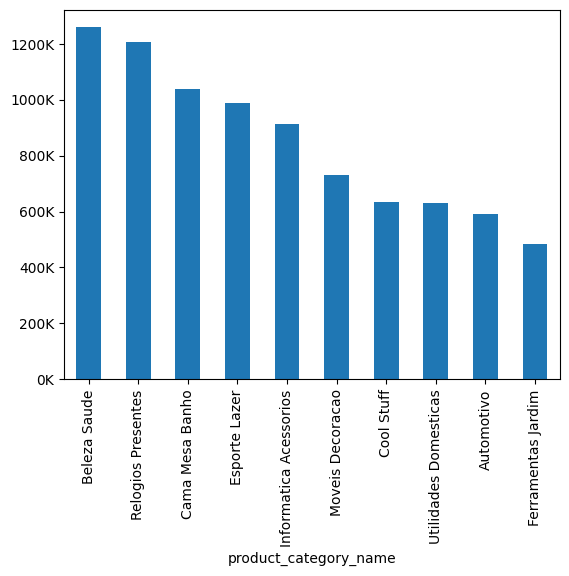

In [64]:
ax = category_revenue.plot(kind='bar')

ax.set_yticklabels([f'{int(x/1000)}K' for x in ax.get_yticks()])

The ‘Beleza Saude’ and ‘Relogios Presentes’ categories generate the highest revenue, indicating strong demand in personal care and gifting segments. Mid-tier categories like home and lifestyle products also contribute significantly, suggesting diversified revenue streams.

In [65]:
total_revenue = category_revenue.sum()
percentage = (category_revenue / total_revenue) * 100

print(percentage.head())

product_category_name
Beleza Saude              14.850019
Relogios Presentes        14.216750
Cama Mesa Banho           12.234472
Esporte Lazer             11.657078
Informatica Acessorios    10.759307
Name: price, dtype: float64


<p style="font-size: 24px;">Section - 3:<p>

<p style="font-size: 18px;"> 1. Monthly Trend + Category Split<p>

In [66]:
# merging all the required data
df_time = order_items.merge(products, on="product_id")\
                     .merge(orders, on="order_id")

In [67]:
# Converting the date column to datetime format
df_time["order_purchase_timestamp"] = pd.to_datetime(df_time["order_purchase_timestamp"])

In [68]:
#Extracting month and year from the date column
df_time["order_month"] = df_time["order_purchase_timestamp"].dt.to_period("M")

In [69]:
#Calculating revenue per month per category
monthly_category = df_time.groupby(
    ["order_month", "product_category_name"]
)["price"].sum().reset_index()


In [70]:
#Pivoting the data to have categories as columns and months as rows
pivot_table = monthly_category.pivot(
    index="order_month",
    columns="product_category_name",
    values="price"
).fillna(0)

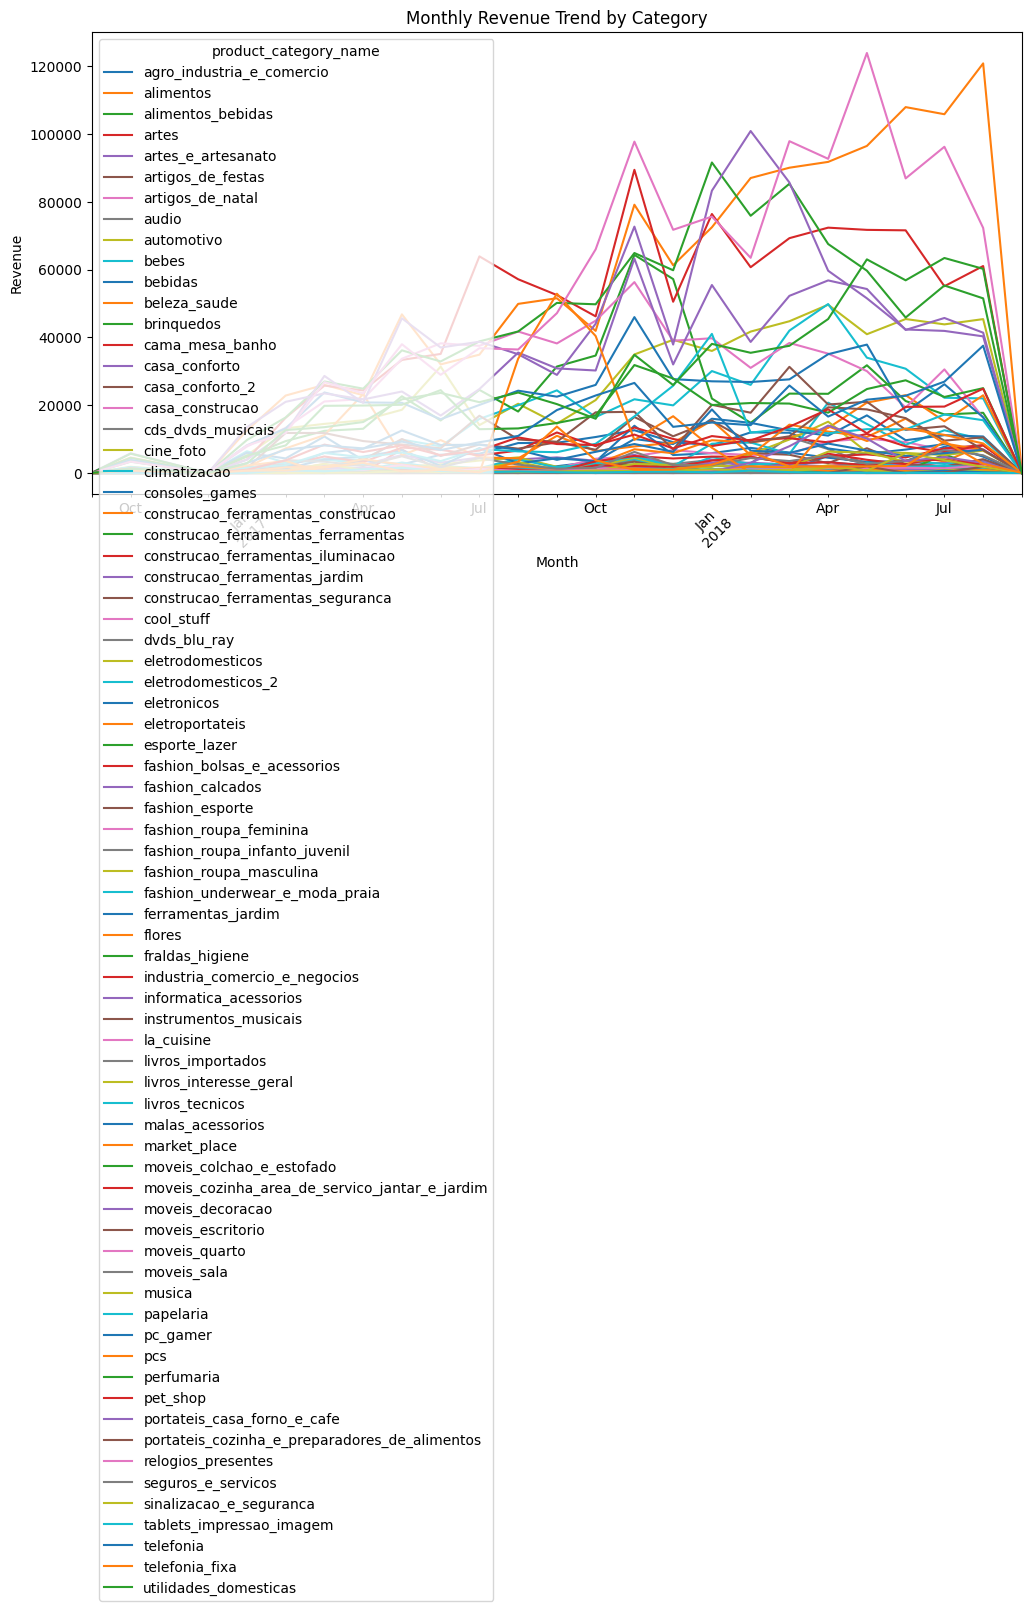

In [71]:
#Ploting the data

pivot_table.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [72]:
#Graph is too messy to intercept so we unclutter

top_categories = category_revenue.head(5).index
top_categories = top_categories.str.lower().str.replace(" ", "_")

pivot_top = pivot_table[top_categories]

In [73]:
pivot_table.columns = pivot_table.columns.str.replace("_", " ").str.title()

pivot_top = pivot_table[category_revenue.head(5).index]

In [74]:
print(pivot_table.columns[:5])
print(top_categories)

Index(['Agro Industria E Comercio', 'Alimentos', 'Alimentos Bebidas', 'Artes',
       'Artes E Artesanato'],
      dtype='str', name='product_category_name')
Index(['beleza_saude', 'relogios_presentes', 'cama_mesa_banho',
       'esporte_lazer', 'informatica_acessorios'],
      dtype='str', name='product_category_name')


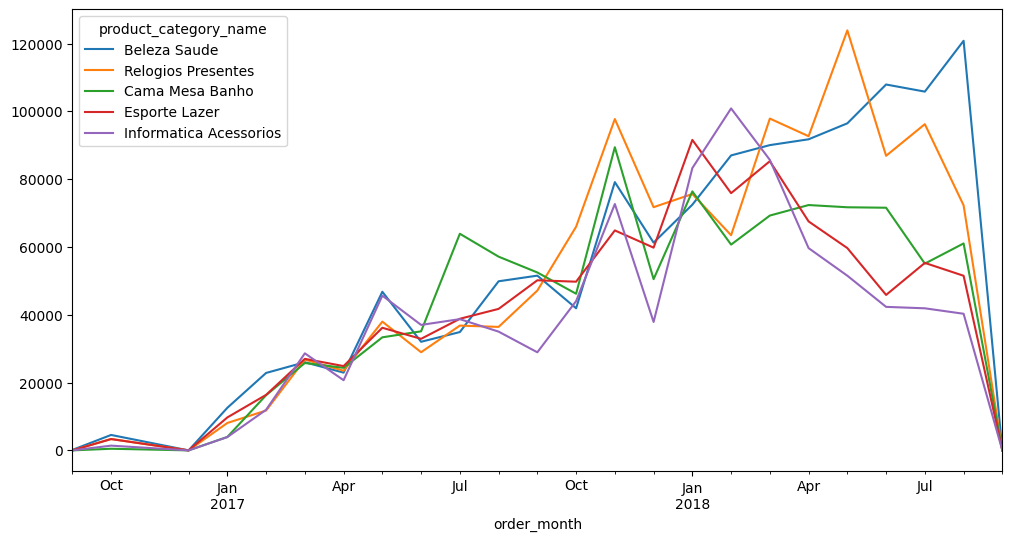

In [75]:
pivot_top.plot(figsize=(12,6))
plt.show()

<Figure size 1200x600 with 0 Axes>

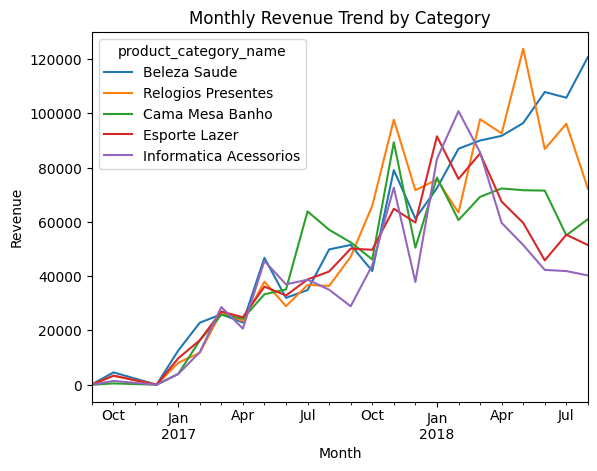

In [76]:
pivot_top = pivot_top.iloc[:-1]

plt.figure(figsize=(12,6))
pivot_top.plot()

plt.title("Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

<p style="font-size: 18px;">2. Revenue Concentration Analysis<p>

In [78]:
#Customer Concentration
top_5_customers = top_customers.sum()
total_revenue = df["order_total"].sum()

customer_contribution = (top_5_customers / total_revenue) * 100
print(customer_contribution)

0.20717673013065951


In [79]:
#Category concentration

top_3_categories = category_revenue.head(3).sum()
total_category_revenue = category_revenue.sum()

category_contribution = (top_3_categories / total_category_revenue) * 100
print(category_contribution)

41.30124148474382


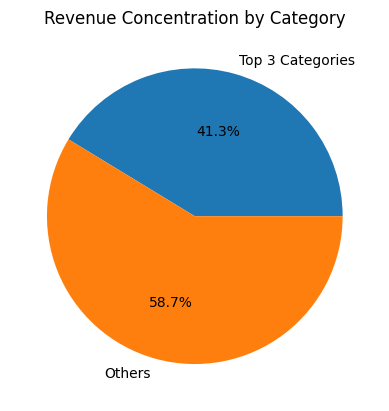

In [80]:
#Visualization

labels = ['Top 3 Categories', 'Others']
values = [top_3_categories, total_category_revenue - top_3_categories]

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Revenue Concentration by Category")
plt.show()

A significant portion of revenue comes from a small number of categories/customers, indicating dependency risk. Any decline in these segments could impact overall revenue

<p style="font-size: 18px;">3. Customer Distribution<p>

In [81]:
# Counting customers by state

customer_state_dist = customers["customer_state"].value_counts()

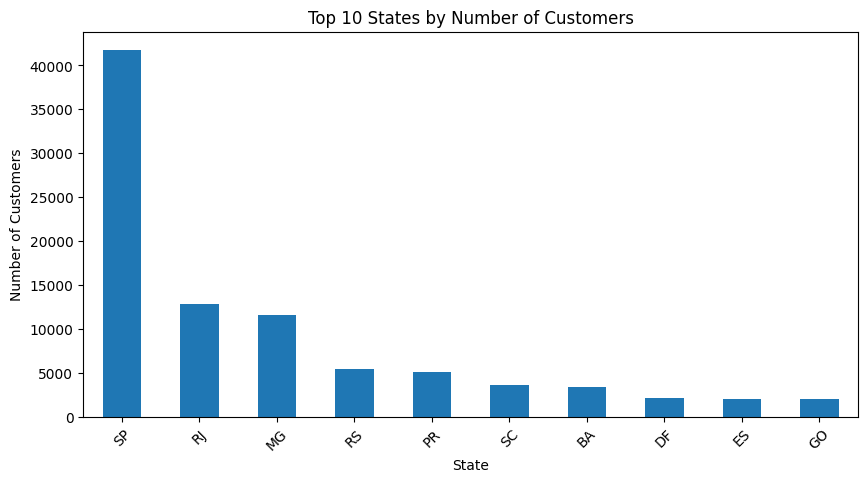

In [82]:
#Plotting



plt.figure(figsize=(10,5))
customer_state_dist.head(10).plot(kind='bar')

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()


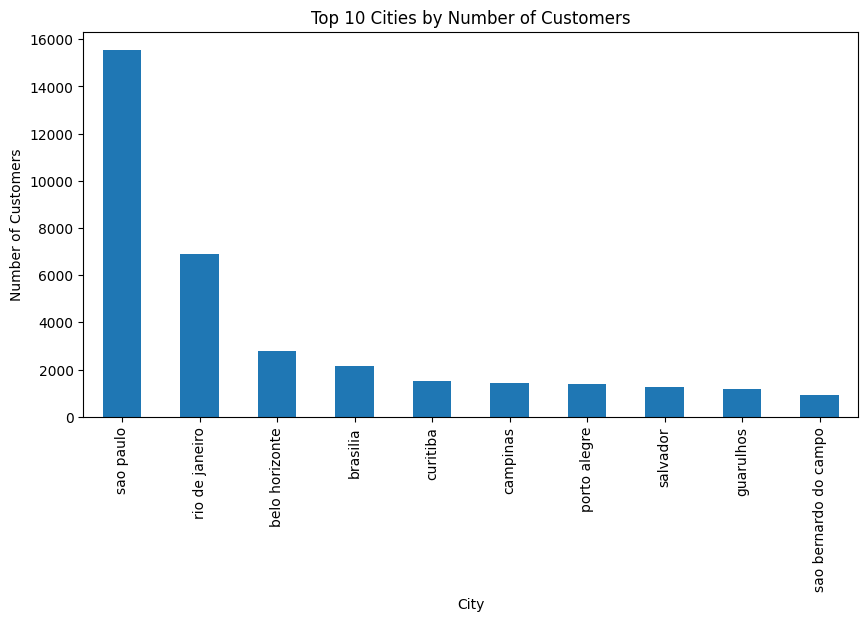

In [83]:
#City level

customer_city_dist = customers["customer_city"].value_counts().head(10)

plt.figure(figsize=(10,5))
customer_city_dist.plot(kind='bar')

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()

In [85]:
print(df_state.columns)

Index(['customer_id', 'customer_unique_id_x', 'customer_zip_code_prefix_x',
       'customer_city_x', 'customer_state_x', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'total_price', 'order_year', 'order_month', 'order_total',
       'customer_unique_id_y', 'customer_zip_code_prefix_y', 'customer_city_y',
       'customer_state_y'],
      dtype='str')


In [86]:
df_state.groupby("customer_state_y")["order_total"].sum()

customer_state_y
AC      24846.58
AL     110570.64
AM      33465.19
AP      21642.70
BA     785935.96
CE     337040.96
DF     429086.24
ES     403734.17
GO     503138.94
MA     196252.09
MG    2301632.11
MS     163507.21
MT     255336.37
PA     251430.41
PB     177670.83
PE     370282.81
PI     135846.77
PR    1052509.00
RJ    2735239.58
RN     115489.10
RO      64957.36
RR      12160.39
RS    1122043.09
SC     777004.31
SE      88214.47
SP    7498937.45
TO      71505.56
Name: order_total, dtype: float64

In [87]:
df_state = df.merge(customers, on="customer_id", suffixes=("", "_cust"))

In [88]:
state_revenue = df_state.groupby("customer_state")["order_total"]\
    .sum()\
    .sort_values(ascending=False)\
    .head(10)

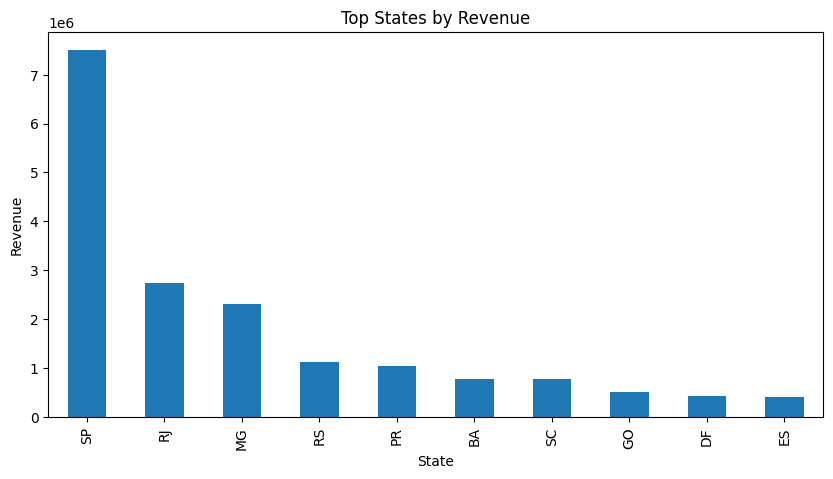

In [89]:
plt.figure(figsize=(10,5))
state_revenue.plot(kind='bar')

plt.title("Top States by Revenue")
plt.ylabel("Revenue")
plt.xlabel("State")

plt.show()

<p style="font-size: 18px;">4. Delivery + Delay Impact<p>

In [90]:
#Merging datasets
df_delivery = orders.merge(reviews, on="order_id")

In [91]:
df_delivery["order_purchase_timestamp"] = pd.to_datetime(df_delivery["order_purchase_timestamp"])
df_delivery["order_delivered_customer_date"] = pd.to_datetime(df_delivery["order_delivered_customer_date"])

In [92]:
df_delivery["delivery_time"] = (
    df_delivery["order_delivered_customer_date"] - df_delivery["order_purchase_timestamp"]
).dt.days

In [93]:
df_delivery = df_delivery.dropna(subset=["delivery_time"])

In [94]:
#Average delivery time

avg_delivery_time = df_delivery["delivery_time"].mean()
print(avg_delivery_time)

12.058956610176528


In [95]:
#Delivery time vs review score

delivery_vs_review = df_delivery.groupby("review_score")["delivery_time"].mean()
print(delivery_vs_review)

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_time, dtype: float64


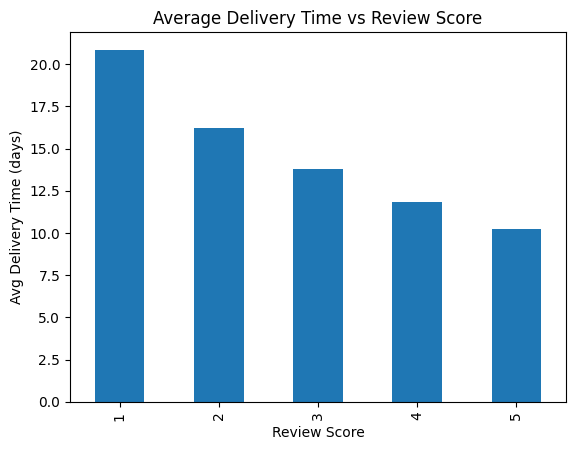

In [96]:
#Plotting

delivery_vs_review.plot(kind='bar')

plt.title("Average Delivery Time vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Avg Delivery Time (days)")

plt.show()

In [97]:
df_delivery["order_estimated_delivery_date"] = pd.to_datetime(df_delivery["order_estimated_delivery_date"])

df_delivery["delay"] = (
    df_delivery["order_delivered_customer_date"] - df_delivery["order_estimated_delivery_date"]
).dt.days

In [98]:
df_delivery.groupby(df_delivery["delay"] > 0)["review_score"].mean()

delay
False    4.289842
True     2.271139
Name: review_score, dtype: float64

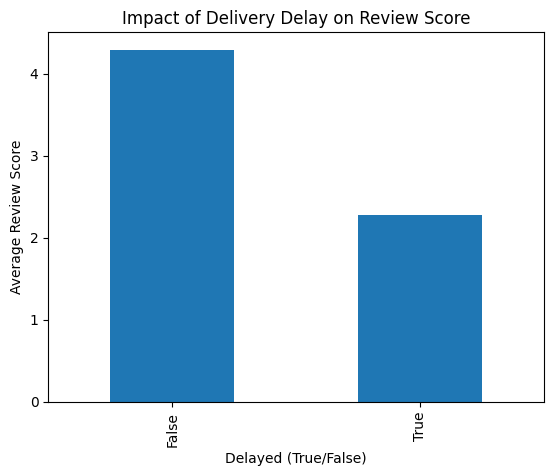

In [99]:
df_delivery.groupby(df_delivery["delay"] > 0)["review_score"].mean().plot(kind='bar')

plt.title("Impact of Delivery Delay on Review Score")
plt.xlabel("Delayed (True/False)")
plt.ylabel("Average Review Score")

plt.show()

The analysis shows that orders delivered on time receive significantly higher review scores (~4.29), whereas delayed orders drop to ~2.27. This indicates that delivery delays have a major negative impact on customer satisfaction and can directly affect customer retention

<p style="font-size: 18px;">5. Customer Segmentation<p>

In [100]:
# Customer total spending

customer_spending = df.groupby("customer_id")["order_total"].sum()

In [101]:
# Creating segments

customer_segments = pd.qcut(customer_spending, q=3, labels=["Low", "Medium", "High"])

In [103]:
#Combining into a df

customer_seg_df = pd.DataFrame({
    "total_spending": customer_spending,
    "segment": customer_segments
})

In [104]:
#Count customers in each segment

segment_counts = customer_seg_df["segment"].value_counts()
print(segment_counts)

segment
Low       32428
High      32426
Medium    32423
Name: count, dtype: int64


In [105]:
#Revenue contribution per segment

segment_revenue = customer_seg_df.groupby("segment")["total_spending"].sum()
print(segment_revenue)

segment
Low        1607890.90
Medium     3628645.17
High      14802944.22
Name: total_spending, dtype: float64


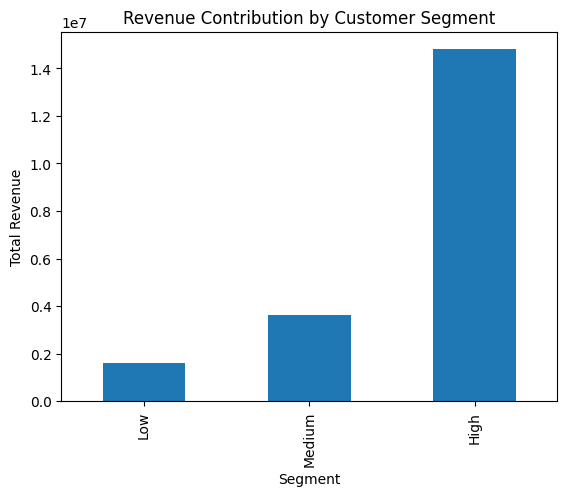

In [106]:
#Plot
segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.show()


In [107]:
avg_spending = customer_seg_df.groupby("segment")["total_spending"].mean()
print(avg_spending)

segment
Low        49.583412
Medium    111.915775
High      456.514656
Name: total_spending, dtype: float64


<p style="font-size: 18px;">6. Repeat Customer Analysis<p>

In [108]:
# Count orders poer customer

customer_orders = df.groupby("customer_id")["order_id"].nunique()

In [110]:
# Classify customers

repeat_status = customer_orders.apply(lambda x: "Repeat" if x > 1 else "One-time")

In [111]:
# Count distribution

repeat_counts = repeat_status.value_counts()
print(repeat_counts)

order_id
One-time    97277
Name: count, dtype: int64


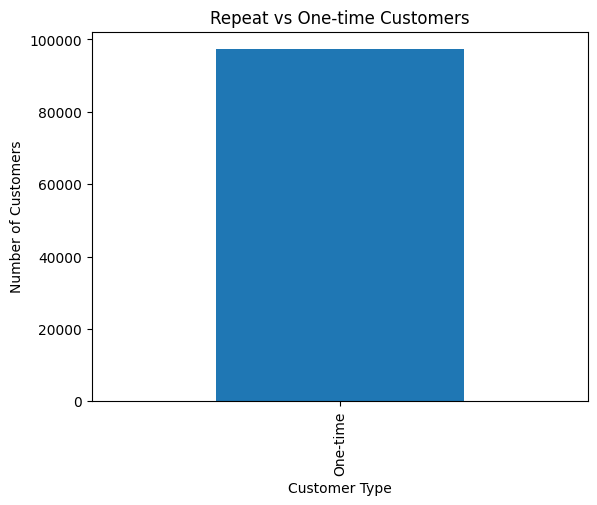

In [112]:
#Plot
repeat_counts.plot(kind='bar')

plt.title("Repeat vs One-time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.show()

In [113]:
#revenue comparision

repeat_df = pd.DataFrame({
    "orders": customer_orders,
    "type": repeat_status
})

repeat_revenue = repeat_df.merge(
    df.groupby("customer_id")["order_total"].sum(),
    on="customer_id"
)

repeat_revenue.groupby("type")["order_total"].sum()

type
One-time    20039480.29
Name: order_total, dtype: float64

The majority of customers are one-time buyers, indicating low retention. This suggests an opportunity to improve customer engagement and loyalty strategies.

<p style="font-size: 18px;">7. Payment vs Spending<p>

In [115]:
# Merging datasets
df_payment = df.merge(payments, on="order_id")

In [116]:
print(df_payment.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'total_price', 'order_year', 'order_month', 'order_total',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='str')


In [117]:
# Average order value per payment type

payment_avg = df_payment.groupby("payment_type")["order_total"].mean()
print(payment_avg)

payment_type
boleto         177.159650
credit_card    184.046735
debit_card     150.613724
voucher        147.603957
Name: order_total, dtype: float64


In [118]:
# Total revenue per payment type

payment_total = df_payment.groupby("payment_type")["order_total"].sum()
print(payment_total)

payment_type
boleto          3994772.95
credit_card    15742621.55
debit_card       250320.01
voucher          908649.96
Name: order_total, dtype: float64


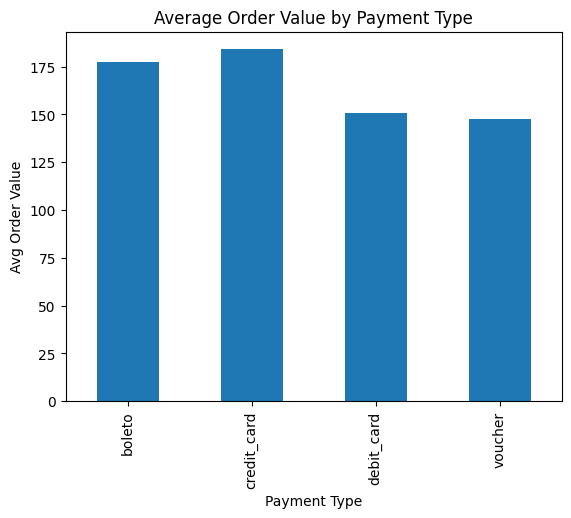

In [119]:
payment_avg.plot(kind='bar')

plt.title("Average Order Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Avg Order Value")

plt.show()

The analysis shows variation in spending behavior across payment methods. Customers using certain payment types, such as credit cards, tend to have higher average order values, indicating different purchasing patterns.

<p style="font-size: 24px;">Section - 5:<p>

<p style="font-size: 18px;">High Revenue but Low Rating<p>

In [120]:
# Merging all the datasets

df_final = order_items.merge(products, on="product_id")\
                      .merge(reviews, on="order_id")

In [121]:
# Category-level metrics
category_analysis = df_final.groupby("product_category_name").agg({
    "price": "sum",           # revenue
    "review_score": "mean"    # avg rating
}).reset_index()

In [122]:
category_analysis["product_category_name"] = category_analysis["product_category_name"]\
    .str.replace("_", " ").str.title()

In [123]:
# identify problematic categories

high_revenue_threshold = category_analysis["price"].quantile(0.75)
low_rating_threshold = category_analysis["review_score"].quantile(0.25)

In [124]:
# Filtering data
problem_categories = category_analysis[
    (category_analysis["price"] >= high_revenue_threshold) &
    (category_analysis["review_score"] <= low_rating_threshold)
]

print(problem_categories)

     product_category_name       price  review_score
13         Cama Mesa Banho  1040140.31      3.895663
44  Informatica Acessorios   914579.39      3.930819
54        Moveis Decoracao   729864.42      3.903493
55       Moveis Escritorio   272339.82      3.493183


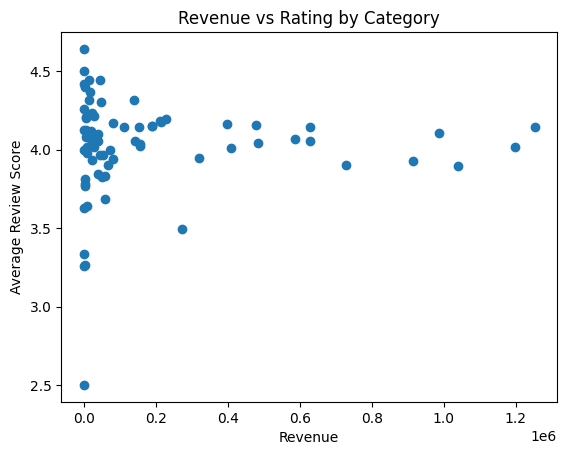

In [125]:
plt.scatter(category_analysis["price"], category_analysis["review_score"])

plt.xlabel("Revenue")
plt.ylabel("Average Review Score")
plt.title("Revenue vs Rating by Category")

plt.show()

This analysis identifies categories that generate high revenue but receive low customer ratings. These categories may have issues such as poor product quality, misleading descriptions, or delivery inefficiencies, and require immediate attention to prevent long-term customer dissatisfaction

<p style="font-size:24px;">Predictive ML Model<p>

Classification Problem: Predict whether a review is Good or Bad.

In [ ]:
#Creating target variables

df_ml = orders.merge(reviews, on="order_id")\
              .merge(order_items, on="order_id")\
              .merge(products, on="product_id")\
              .merge(payments, on="order_id")

df_ml["target"] = df_ml["review_score"].apply(lambda x: 1 if x >= 4 else 0)

In [134]:
#Feature Engineering

import pandas as pd

# Convert dates
df_ml["order_purchase_timestamp"] = pd.to_datetime(df_ml["order_purchase_timestamp"])
df_ml["order_delivered_customer_date"] = pd.to_datetime(df_ml["order_delivered_customer_date"])
df_ml["order_estimated_delivery_date"] = pd.to_datetime(df_ml["order_estimated_delivery_date"])

# Delivery time
df_ml["delivery_time"] = (
    df_ml["order_delivered_customer_date"] - df_ml["order_purchase_timestamp"]
).dt.days

# Delay
df_ml["delay"] = (
    df_ml["order_delivered_customer_date"] - df_ml["order_estimated_delivery_date"]
).dt.days

# Total order value
df_ml["order_total"] = df_ml.groupby("order_id")["price"].transform("sum")

In [135]:
features = [
    "delivery_time",
    "delay",
    "order_total",
    "payment_type",
    "product_category_name"
]

df_ml = df_ml[features + ["target"]]

In [136]:
df_ml = df_ml.dropna()

In [137]:
#Encoding categorical data

df_ml = pd.get_dummies(df_ml, columns=[
    "payment_type",
    "product_category_name"
], drop_first=True)

In [139]:
#Train-test split

from sklearn.model_selection import train_test_split

X = df_ml.drop("target", axis=1)
y = df_ml["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<p style="font-size:18px;">ML model training<p>

In [141]:
# Linear Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [142]:
# Decision tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [143]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [144]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

<p style="font-size:18px;">Model Evaluation<p>

In [145]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.7896851680134234
              precision    recall  f1-score   support

           0       0.76      0.14      0.24      5265
           1       0.79      0.99      0.88     17382

    accuracy                           0.79     22647
   macro avg       0.78      0.56      0.56     22647
weighted avg       0.78      0.79      0.73     22647


Decision Tree
Accuracy: 0.7726409678986179
              precision    recall  f1-score   support

           0       0.51      0.55      0.53      5265
           1       0.86      0.84      0.85     17382

    accuracy                           0.77     22647
   macro avg       0.69      0.69      0.69     22647
weighted avg       0.78      0.77      0.78     22647


Random Forest
Accuracy: 0.8349891817900825
              precision    recall  f1-score   support

           0       0.72      0.47      0.57      5265
           1       0.86      0.95      0.90     17382

    accuracy                           0.83 

In [146]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

print(results)

{'Logistic Regression': 0.7896851680134234, 'Decision Tree': 0.7726409678986179, 'Random Forest': 0.8349891817900825, 'Gradient Boosting': 0.8012098732723981}


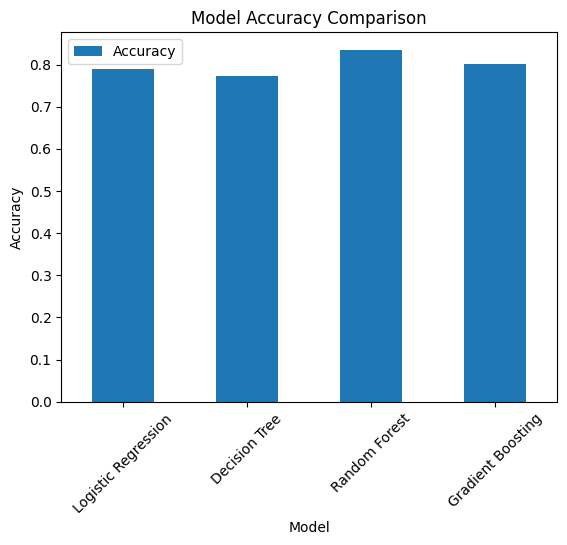

In [153]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

results_df.plot(x="Model", y="Accuracy", kind="bar")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=45)

plt.show()

<p style="font-size:24px;">K means Clustering: Customer Segmentation<p>

In [ ]:
customer_data = df.groupby("customer_id").agg({
    "order_total": "sum",          
    "order_id": "nunique"          
}).rename(columns={
    "order_total": "total_spending",
    "order_id": "order_count"
})

In [148]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)

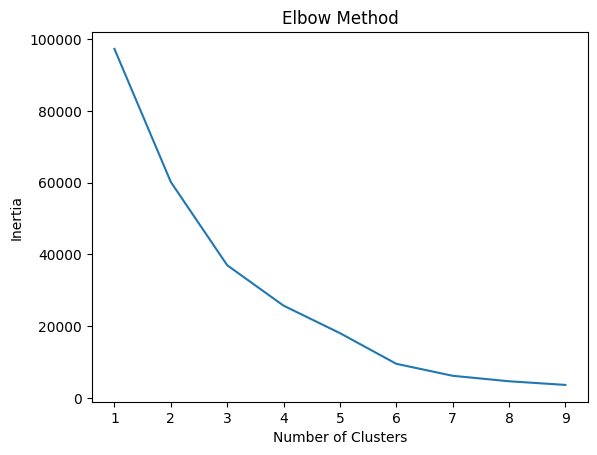

In [149]:
# Finding optimal clusters using Elbow method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [150]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_data["cluster"] = kmeans.fit_predict(scaled_data)

In [151]:
customer_data.groupby("cluster").mean()

,total_spending,order_count
cluster,,
0,181.861558,1.0
1,49065.233333,1.0
2,4564.021983,1.0


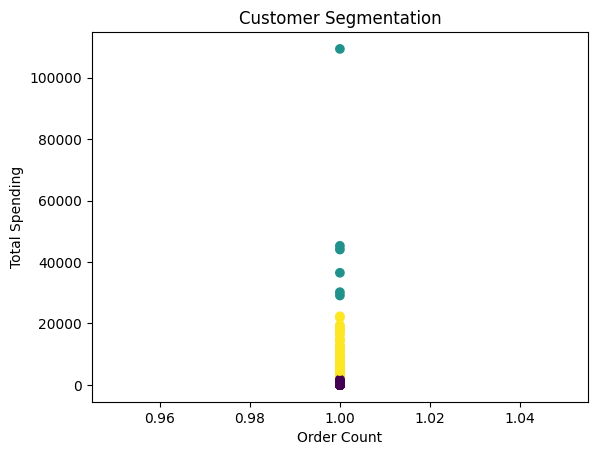

In [152]:
plt.scatter(
    customer_data["order_count"],
    customer_data["total_spending"],
    c=customer_data["cluster"]
)

plt.xlabel("Order Count")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")
plt.show()

K-Means clustering was applied to identify hidden customer segments based on spending and purchase frequency. The analysis revealed distinct groups such as low-value, medium-value, and high-value customers

<p style="font-size:24px;">Conclusion<p>

The project successfully analyzes retail data to uncover key business insights. It identifies high-value customers, top-performing categories, seasonal trends, and the impact of delivery performance on customer satisfaction.

The analysis also highlights areas of improvement such as delivery delays and low-rated high-revenue categories. These insights can help businesses optimize operations, improve customer experience, and increase profitability.